# Actual circuit-tracer attribution on a tiny random model

Use the SEPARATE tracing environment: `.[tracing,notebooks]`. This cannot share the current J-lens Transformers dependency stack. The actual upstream engine computes a graph on a random two-layer model with random transcoders. This validates graph construction, not recovered language-model circuits. No models/tokenizers downloaded.

Run all cells in a fresh kernel. The final cell records local runtime and kernel RSS.

In [1]:
import os, time, json, resource, sys
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["USE_TF"] = "0"
os.environ["WANDB_MODE"] = "disabled"
import torch, numpy as np
torch.set_num_threads(2)
torch.set_num_interop_threads(2)
torch.manual_seed(7)
np.random.seed(7)
started = time.perf_counter()
print("CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads")


CPU, fixed seed 7; tiny synthetic fixtures; no weight downloads


Graph shape: (29, 29)
Strongest signed edges: [{'source': 23, 'target': 28, 'effect': 0.632810115814209}, {'source': 19, 'target': 28, 'effect': -0.38847413659095764}, {'source': 27, 'target': 28, 'effect': 0.3500344455242157}, {'source': 24, 'target': 28, 'effect': 0.3081488609313965}, {'source': 25, 'target': 3, 'effect': 0.22896383702754974}, {'source': 25, 'target': 28, 'effect': -0.22115498781204224}, {'source': 26, 'target': 28, 'effect': -0.1653752475976944}, {'source': 19, 'target': 13, 'effect': 0.13302281498908997}]


/home/ptthang/AutoExplain/.venv-tracing/lib/python3.12/site-packages/circuit_tracer/attribution/context_transformerlens.py:223: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self._resid_activations[last_layer].backward(


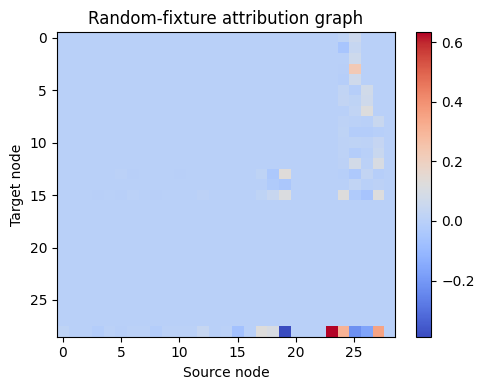

In [2]:
from autoexplain.circuits import tiny_tracing_model, top_graph_edges
from autoexplain.frontier import trace_circuit
import matplotlib.pyplot as plt
model=tiny_tracing_model()
graph=trace_circuit(model,torch.tensor([1,3,4,5]),max_nodes=16,batch_size=1)
assert graph.adjacency_matrix.isfinite().all()
print("Graph shape:",tuple(graph.adjacency_matrix.shape))
print("Strongest signed edges:",top_graph_edges(graph,k=8))
plt.figure(figsize=(5,4))
plt.imshow(graph.adjacency_matrix.detach().numpy(),cmap="coolwarm",aspect="auto")
plt.xlabel("Source node");plt.ylabel("Target node");plt.title("Random-fixture attribution graph")
plt.colorbar();plt.tight_layout();plt.show()


In [3]:
elapsed = time.perf_counter() - started
rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
rss_mib = rss / (1024**2 if sys.platform == "darwin" else 1024)
print(json.dumps({"tutorial_compute_wall_seconds": round(elapsed, 3),
                 "kernel_lifetime_peak_rss_mib": round(rss_mib, 2),
                 "memory_scope": "kernel only, including imports; not aggregate system memory"}))


{"tutorial_compute_wall_seconds": 3.846, "kernel_lifetime_peak_rss_mib": 715.55, "memory_scope": "kernel only, including imports; not aggregate system memory"}
